In [12]:
import numpy as np
import matplotlib.pyplot as plt

## Fisher's Discriminant Analysis
$$
% Tags for search:
% LDA
% FDA
% Linear Discriminant Analysis
% Fisher Discriminant Analysis
% Fishers Linear Discriminant
$$

In [13]:
# expects data on the form (if data is not on this form do X.T in function input)
X = np.array([  [ 1,  2],
                [ 4,  6],
                [ 8,  3],
                [ 3, -1],
                [-1, -5],
                [-8, -9]])
t = np.array([0, 0, 1, 1, 2, 2]) # uses classes as index so keep that in mind if it isnt 0 indexed

In [14]:
def class_means(X, t):
    classes = np.unique(t)
    ms = list(np.zeros(len(classes)))
    Ns = list(np.zeros(len(classes)))
    N = len(X)
    for n in range(N):
        Ns[t[n]] += 1
        ms[t[n]] += X[n]
    
    return_array = []
    for m, n in zip(ms, Ns):
        return_array.append(m/n)
    return return_array

def LDA_scatter_matrix(X, t):
    m = X.mean(axis=0)
    means = class_means(X, t)
    # for i, mean in enumerate(means):
    #     print(f"Mean for class {i+1}:\n", mean)

    K = len(means)
    N = len(X)

    # https://stackoverflow.com/questions/28663856/how-do-i-count-the-occurrence-of-a-certain-item-in-an-ndarray
    unique, counts = np.unique(t, return_counts=True)
    Ns = dict(zip(unique, counts))
    
    S_W = 0
    S_B = 0
    for k in range(K):
        S_B += Ns[k] * np.outer(means[k] - m, means[k] - m)
        
        for n in range(N):
            if t[n] == k:
                S_W += (X[n] - means[k])[:, np.newaxis] @ (X[n] - means[k])[:, np.newaxis].T
    
    return S_B, S_W

def projection_matrix(X, t, D_prime=1):
    S_B, S_W = LDA_scatter_matrix(X, t)
    # print("S_B:\n", S_B)
    # print("S_W:\n", S_W)
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
    sorted_indices = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, sorted_indices]
    W = eigvecs[:, :D_prime]
    return W

In [15]:
w = projection_matrix(X, t)
print(f"w = \n{w}")

w = 
[[ 0.5671532 ]
 [-0.82361232]]


### Plot

In [ ]:
def plot_lda(X, t, w, colors=['b', 'r', 'g'], markers=['o', 's', '^']):
    plt.title("LDA Projection")
    plt.axis('equal')
    plt.grid()
    
    labels = np.unique(t)
    for i, label in enumerate(labels):
        plt.scatter(*X[t == label].T, label=f'Class {label}', color=colors[i], marker=markers[i])
    n = np.linspace(np.min(X[:,0])/w[0], np.max(X[:,0])/w[0], 100)
    plt.plot(n*w[0], n*w[1], label='Projection line')

    plt.legend()

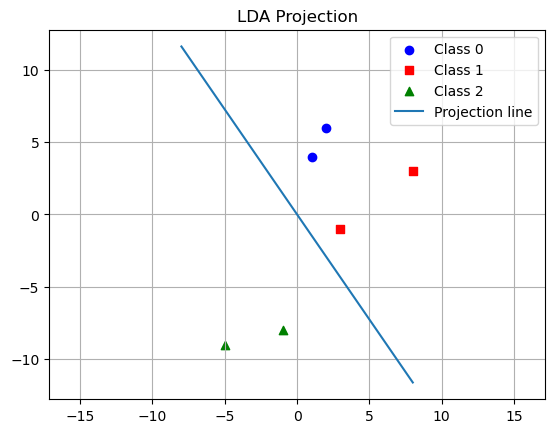

In [25]:
plot_lda(X, t, w)

## Nearest centroid

In [ ]:
def nearest_centroid_based_class(x, mus, covariances):
    K = len(mus)
    distances = np.zeros((K))
    for k in range(K):
        distances[k] = (x - mus[k]).T @ np.linalg.inv(covariances[k]) @ (x - mus[k])
    return np.argmin(distances)